In [1]:
!pip install koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
!pip install xmltodict

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import requests
import pandas as pd
import xmltodict
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [4]:
# 1. API 설정
api_key = "3982adaa31cbed887167fbe7cafe0157c665981f3711dba632b3630b42f7cf69"
url = 'http://apis.data.go.kr/B552584/EvCharger/getChargerInfo'

In [5]:
params = {
    'serviceKey': api_key,  # 공공데이터포털에서 발급받은 인증키
    'pageNo': '1',              
    "numOfRows": "100",   # 가져올 데이터 수        
}

response = requests.get(url, params=params)
dict_data = xmltodict.parse(response.content)

# 실제 데이터 리스트 추출
items = dict_data['response']['body']['items']['item']
df = pd.DataFrame(items)

In [6]:
df.shape

(100, 37)

In [7]:
df.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

In [8]:
df.isnull().sum()

statNm           0
statId           0
chgerId          0
chgerType        0
addr             0
addrDetail       0
location         0
lat              0
lng              0
useTime          0
busiId           0
bnm              0
busiNm           0
busiCall         0
stat             0
statUpdDt        0
lastTsdt         0
lastTedt         0
nowTsdt         81
powerType      100
output           0
method           0
zcode            0
zscode           0
kind             0
kindDetail       0
parkingFree      0
note           100
limitYn          0
limitDetail    100
delYn            0
delDetail      100
trafficYn        0
year             0
floorNum         0
floorType        0
maker            0
dtype: int64

In [9]:
df = df.drop_duplicates(subset=['statNm', 'addr'])

In [10]:
# 1. 시/도 파생 변수 생성
df['시도'] = df['addr'].str.split().str[0].str[:2]

# 2. 충전기 타입 범주화
chger_map = {
    '01': '완속',
    '03': '급속',
    '06': '초급속'
}
df['충전타입'] = df['chgerType'].map(chger_map).fillna('기타')

# 3. 24시간 이용 가능 여부
df['24시간가능'] = df['useTime'].str.contains('24시간', na=False)

# 확인
print(df[['addr', '시도', 'chgerType', '충전타입', 'useTime', '24시간가능']].head(10))

                            addr  시도 chgerType 충전타입    useTime  24시간가능
0            서울특별시 관악구 낙성대로4가길 5  서울        06  초급속  24시간 이용가능    True
1           서울특별시 서초구 양재대로12길 74  서울        06  초급속  24시간 이용가능    True
2               서울특별시 송파구 중대로 80  서울        06  초급속  24시간 이용가능    True
3            서울특별시 은평구 수색로 342-1  서울        06  초급속  24시간 이용가능    True
4             서울특별시 종로구 인사동5길 29  서울        06  초급속  24시간 이용가능    True
5    제주특별자치도 서귀포시 남원읍 중산간동로 6862  제주        06  초급속  24시간 이용가능    True
6        제주특별자치도 서귀포시 색달동 2889-1  제주        06  초급속  24시간 이용가능    True
11     제주특별자치도 서귀포시 표선면 표선리 2103  제주        06  초급속  24시간 이용가능    True
12        제주특별자치도 서귀포시 회수동 788-2  제주        06  초급속  24시간 이용가능    True
13  제주특별자치도 제주시 구좌읍 일주동로 2706-40  제주        06  초급속  24시간 이용가능    True


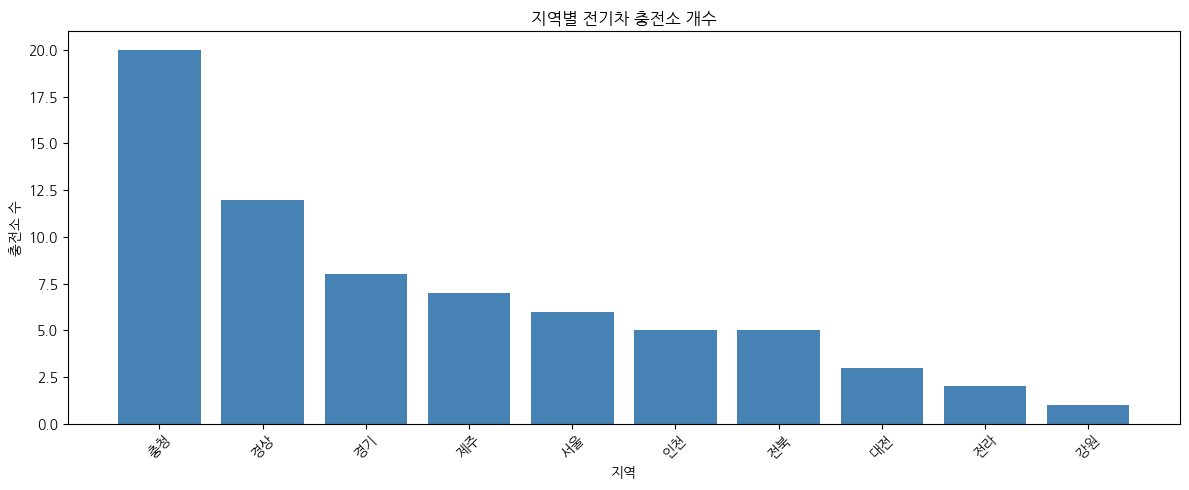

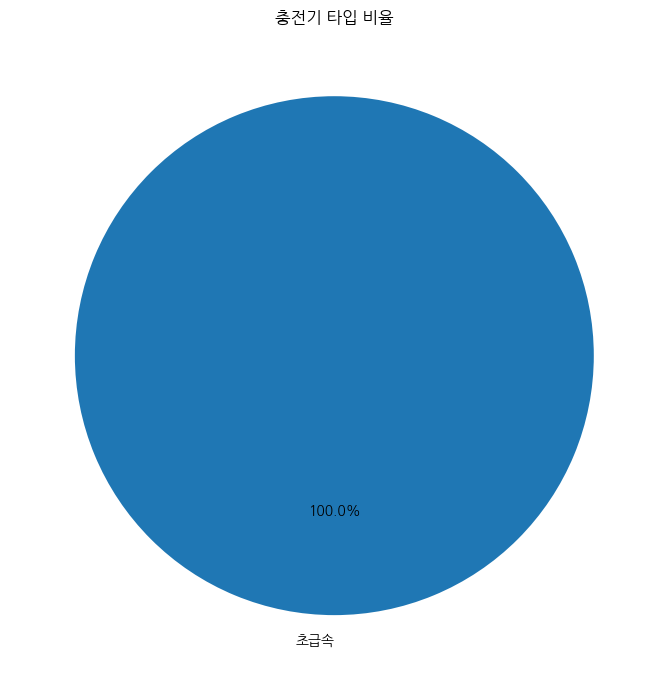

<Figure size 1200x500 with 0 Axes>

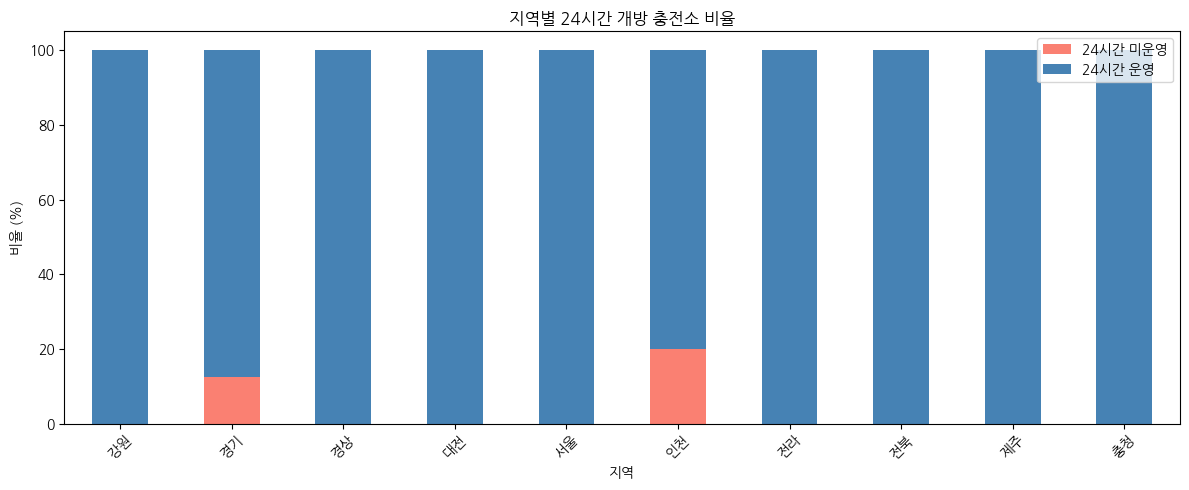

In [11]:

import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ===== 시각화 1: 지역별 충전소 개수 Bar Chart =====
plt.figure(figsize=(12, 5))
sido_count = df['시도'].value_counts().sort_values(ascending=False)
plt.bar(sido_count.index, sido_count.values, color='steelblue')
plt.title('지역별 전기차 충전소 개수')
plt.xlabel('지역')
plt.ylabel('충전소 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== 시각화 2: 충전기 타입 비율 Pie Chart =====
plt.figure(figsize=(7, 7))
type_count = df['충전타입'].value_counts()
plt.pie(type_count.values, labels=type_count.index, autopct='%1.1f%%', startangle=90)
plt.title('충전기 타입 비율')
plt.tight_layout()
plt.show()

# ===== 시각화 3: 지역별 24시간 개방 비율 Stacked Bar Chart =====
plt.figure(figsize=(12, 5))
cross = pd.crosstab(df['시도'], df['24시간가능'])
cross.columns = ['24시간 미운영', '24시간 운영']
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100  # 비율로 변환
cross_pct.plot(kind='bar', stacked=True, color=['salmon', 'steelblue'], figsize=(12, 5))
plt.title('지역별 24시간 개방 충전소 비율')
plt.xlabel('지역')
plt.ylabel('비율 (%)')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
#1. 경기, 서울, 제주 순으로 충전소가 많으며, 수도권 집중 현상이 뚜렷하다.
#2. 충전기 타입은 완속이 가장 많은 비율을 차지하며, 초급속은 아직 보급률이 낮다.
#3. 제주는 24시간 개방 충전소 비율이 타 지역 대비 높아 EV 인프라가 잘 갖춰져 있다.